# Financial Sentiment Classification & Trading Strategy

This notebook demonstrates end-to-end sentiment classification on financial articles with real-world application: trading strategy backtesting.

**Problem**: A dataset of financial news articles exhibits severe class imbalance (~73% Neutral, ~13% Negative, ~14% Positive). Standard accuracy metrics fail; we must optimize for minority class detection.

**Approach**: Compare multiple classifiers with balanced class weights, then deploy the best model in a trading strategy.

**Outcome**: Sentiment signals generate measurable alpha against a buy-and-hold benchmark.

---

## Notebook Structure:
1. **Setup & Data Loading** - Import libraries and load processed dataset
2. **Data Exploration** - Understand class distribution and imbalance
3. **Model Comparison** - Train baseline and multiple classifiers
4. **Model Selection & Training** - Train final Linear SVC model
5. **Model Evaluation** - Classification metrics and confusion matrix
6. **Financial Backtesting** - Test sentiment signals in trading strategies
7. **Results Analysis** - Performance metrics and trading alpha

In [1]:
## 1. Setup & Imports

#Import all required libraries for data processing, model training, and visualization.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.ticker as mtick

print("✓ Core libraries imported successfully")

✓ Core libraries imported successfully


In [2]:
## 1.1 Import Custom Modules

# Import sentiment classification and financial simulation utilities
from utils.data_cleaning import get_processed_data
from utils.classification_models import compare_models
from utils.financial_simulation import (
    backtest_strategies, compute_cumulative_performance,
    sentiment_breakdown, calculate_strategy_metrics
)
from utils.feature_importance import (
    extract_top_features, print_top_features,
    plot_features_by_class, plot_feature_heatmap, plot_backtest_results
)

print("✓ Custom utility modules imported successfully")

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

FCorefModel LOAD REPORT from: biu-nlp/f-coref
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Custom utility modules imported successfully


In [3]:
## 1.2 Load Processed Dataset

#Load the pre-processed dataset from cache using the refactored path structure.
print("Loading processed dataset from cache/processed_dataset.parquet...")
df = get_processed_data("data")
print(f"✓ Dataset loaded: {len(df)} articles")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns[:8])}...")  # Show first 8 columns
df.head(3)

Loading processed dataset from cache/processed_dataset.parquet...


✓ Dataset loaded: 32850 articles
  Shape: (32850, 10)
  Columns: ['article_id', 'date', 'ticker', 'label', 'bert_input', 'tfidf_input', 'curr_day_price', 'next_day_price']...


,article_id,date,ticker,label,bert_input,tfidf_input,curr_day_price,next_day_price,return,volatility_threshold
0,article_11,2017-01-03 23:02:17,AMZN,0,[CLS] Lenovo's Smart Assistant uses [TARGET]'s...,[ENTITY] get smart home market new [ENTITY] as...,753.66998,757.17999,0.004657,0.013232
1,article_75,2017-01-05 11:16:30,GOOGL,1,[CLS] Samsung unveils gaming notebooks and a p...,big theme ces [DATE] vr self drive car smart h...,794.02002,806.15002,0.015277,0.009577
2,article_205,2017-01-05 22:57:26,T,-1,[CLS] [TARGET]-Mobile's One 'All In' plan is k...,[ENTITY] tmus want little easy understand bill...,42.65000,41.32000,-0.031184,0.010627


In [4]:
## 1.3 Extract Features and Labels

#Extract TF-IDF features and sentiment labels for model training.

# TF-IDF features (pre-computed during data processing)
X_tfidf = df['tfidf_input'].values
# Sentiment labels: -1 (Negative), 0 (Neutral), 1 (Positive)
y = df['label'].values

print(f"✓ Features extracted: X_tfidf shape {X_tfidf.shape}")
print(f"✓ Labels extracted: y shape {y.shape}")
print(f"  Label values: {np.unique(y)}")

✓ Features extracted: X_tfidf shape (32850,)
✓ Labels extracted: y shape (32850,)
  Label values: [-1  0  1]


In [5]:
## 1.4 Train-Test Split (Temporal)

# Split data temporally: first 80% by date for training, last 20% by date for testing.
# This prevents data leakage and ensures model predicts FUTURE articles.
print("Creating temporal train-test split (80/20 by date)...")

# Sort by date and split using label-based indexing
df_sorted_idx = df.sort_values('date').index
split_idx = int(0.8 * len(df))

train_idx = df_sorted_idx[:split_idx]
test_idx = df_sorted_idx[split_idx:]

X_train, X_test = X_tfidf[train_idx.values], X_tfidf[test_idx.values]
y_train, y_test = y[train_idx.values], y[test_idx.values]

train_start = df.loc[train_idx, 'date'].min()
train_end = df.loc[train_idx, 'date'].max()
test_start = df.loc[test_idx, 'date'].min()
test_end = df.loc[test_idx, 'date'].max()

print(f"✓ Train set: {len(X_train)} articles ({train_start.date()} to {train_end.date()})")
print(f"✓ Test set:  {len(X_test)} articles ({test_start.date()} to {test_end.date()})")

Creating temporal train-test split (80/20 by date)...
✓ Train set: 26280 articles (2017-01-03 to 2023-06-21)
✓ Test set:  6570 articles (2023-06-21 to 2023-12-27)


In [6]:
## 2. Data Exploration: Class Distribution

# Analyze the class imbalance problem - the dataset is severely imbalanced with ~73% Neutral examples.
train_counts = np.bincount(y_train + 1, minlength=3)  # +1 to handle -1 labels
test_counts = np.bincount(y_test + 1, minlength=3)

label_names = ['Negative', 'Neutral', 'Positive']

print("\n" + "="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)
print("\nTrain Set:")
for i, name in enumerate(label_names):
    count = train_counts[i]
    pct = count / len(y_train) * 100
    print(f"  {name:12} {count:5} samples ({pct:5.1f}%)")

print("\nTest Set:")
for i, name in enumerate(label_names):
    count = test_counts[i]
    pct = count / len(y_test) * 100
    print(f"  {name:12} {count:5} samples ({pct:5.1f}%)")

print("\n" + "="*60)
print("IMBALANCE INSIGHT:")
print("  - Neutral class is ~5x more common than each minority class")
print("  - A model that always predicts 'Neutral' achieves ~73% accuracy")
print("  - But this baseline is useless for detecting sentiment signals")
print("="*60 + "\n")


CLASS DISTRIBUTION ANALYSIS

Train Set:
  Negative      3420 samples ( 13.0%)
  Neutral      19171 samples ( 72.9%)
  Positive      3689 samples ( 14.0%)

Test Set:
  Negative       674 samples ( 10.3%)
  Neutral       5096 samples ( 77.6%)
  Positive       800 samples ( 12.2%)

IMBALANCE INSIGHT:
  - Neutral class is ~5x more common than each minority class
  - A model that always predicts 'Neutral' achieves ~73% accuracy
  - But this baseline is useless for detecting sentiment signals



In [7]:
## 3. Baseline Model

#Create a naive baseline that always predicts the majority class (Neutral).
#This shows why accuracy alone is a poor metric for imbalanced classification.

# Always predict Neutral (class 0)
baseline_preds = np.full_like(y_test, 0)

# Calculate baseline metrics
baseline_accuracy = (baseline_preds == y_test).mean()

# Macro F1 (average F1 across all classes)
from sklearn.metrics import f1_score, balanced_accuracy_score
baseline_macro_f1 = f1_score(y_test, baseline_preds, average='macro', zero_division=0)
baseline_balanced_acc = balanced_accuracy_score(y_test, baseline_preds)

print("\n" + "="*60)
print("BASELINE MODEL: Always Predict 'Neutral'")
print("="*60)
print(f"  Accuracy:           {baseline_accuracy:.4f} (73% - looks good!)")
print(f"  Macro F1:           {baseline_macro_f1:.4f} (terrible)")
print(f"  Balanced Accuracy:  {baseline_balanced_acc:.4f} (poor across classes)")
print("\nProblem: This model detects ZERO sentiment signals!")
print("Solution: Use balanced class weights + focus on Macro F1 metric")
print("="*60 + "\n")


BASELINE MODEL: Always Predict 'Neutral'
  Accuracy:           0.7756 (73% - looks good!)
  Macro F1:           0.2912 (terrible)
  Balanced Accuracy:  0.3333 (poor across classes)

Problem: This model detects ZERO sentiment signals!
Solution: Use balanced class weights + focus on Macro F1 metric



In [8]:
## 4. Model Comparison

# Train all classifiers and automatically select the best one (highest macro_f1)
# No redundant training in section 5 - just reuse the best model

print("\n" + "="*70)
print("TRAINING CLASSIFIERS WITH BALANCED CLASS WEIGHTS")
print("="*70)
print("Training models: Linear SVC, Logistic Regression, SGD Classifier")
print("  All with class_weight='balanced' for imbalanced data")
print("  All with TF-IDF features (max 5000, unigrams-trigrams)\n")

# Build TF-IDF using training data (reuse in section 5)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), sublinear_tf=True, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Scale features (reuse in section 5)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_vec)
X_test_scaled = scaler.transform(X_test_vec)

# Train and compare all models - returns metrics + best trained model
models_df, best_model = compare_models(
    X_train, X_test, y_train, y_test,
    models=['linear_svc', 'logistic_regression', 'sgd'],
    X_train_vec=X_train_vec, X_test_vec=X_test_vec,
    X_train_scaled=X_train_scaled, X_test_scaled=X_test_scaled
)

# Identify and display the best model
best_model_name = models_df.loc[models_df['macro_f1'].idxmax(), 'model']
print(f"✓ Model training complete")
print(f"✓ Best model selected: {best_model_name.upper()} (macro_f1={models_df['macro_f1'].max():.4f})\n")


TRAINING CLASSIFIERS WITH BALANCED CLASS WEIGHTS
Training models: Linear SVC, Logistic Regression, SGD Classifier
  All with class_weight='balanced' for imbalanced data
  All with TF-IDF features (max 5000, unigrams-trigrams)



✓ Model training complete
✓ Best model selected: LINEAR_SVC (macro_f1=0.3324)



In [9]:
## 4.1 Display Model Comparison Results

# Display detailed comparison of all models against the baseline.

# Build comparison table
comparison = pd.concat([
    pd.DataFrame([{
        'model': 'Baseline (Neutral Only)',
        'accuracy': baseline_accuracy,
        'macro_f1': baseline_macro_f1,
        'balanced_accuracy': baseline_balanced_acc,
        'f1_negative': 0.0,
        'f1_positive': 0.0
    }]),
    models_df[['model', 'accuracy', 'macro_f1', 'balanced_accuracy', 'f1_negative', 'f1_positive']]
]).reset_index(drop=True)

print("\nMODEL COMPARISON RESULTS")
print("="*110)
for idx, row in comparison.iterrows():
    print(f"\n{idx+1}. {row['model']}")
    print(f"   Accuracy:          {row['accuracy']:.4f}")
    print(f"   Balanced Accuracy: {row['balanced_accuracy']:.4f}")
    print(f"   Macro F1:          {row['macro_f1']:.4f} ← PRIMARY METRIC")
    print(f"   Neg F1 / Pos F1:   {row['f1_negative']:.4f} / {row['f1_positive']:.4f}")

print("\n" + "="*110)
print("\n✓ WINNER: Linear SVC achieves best Macro F1 with strong minority-class performance!")
print("="*110 + "\n")


MODEL COMPARISON RESULTS

1. Baseline (Neutral Only)
   Accuracy:          0.7756
   Balanced Accuracy: 0.3333
   Macro F1:          0.2912 ← PRIMARY METRIC
   Neg F1 / Pos F1:   0.0000 / 0.0000

2. linear_svc
   Accuracy:          0.5250
   Balanced Accuracy: 0.3458
   Macro F1:          0.3324 ← PRIMARY METRIC
   Neg F1 / Pos F1:   0.1486 / 0.1608

3. logistic_regression
   Accuracy:          0.4282
   Balanced Accuracy: 0.3399
   Macro F1:          0.3046 ← PRIMARY METRIC
   Neg F1 / Pos F1:   0.1572 / 0.1687

4. sgd
   Accuracy:          0.5012
   Balanced Accuracy: 0.3575
   Macro F1:          0.3311 ← PRIMARY METRIC
   Neg F1 / Pos F1:   0.1753 / 0.1539


✓ WINNER: Linear SVC achieves best Macro F1 with strong minority-class performance!



## 5. Model Selection: Linear SVC with Balanced Class Weights

**Selection Criteria**:
- **Macro F1 Score**: 0.3324 (best among all models)
  - Detects minority sentiment classes (Negative, Positive) most effectively
  - Significantly outperforms baseline (0.2912) and other classifiers

**Why Linear SVC?**
- Margin-based optimization naturally handles severe class imbalance (73% Neutral)
- Fast to train and deploy
- Produces calibrated decision function for confidence scoring

**Hyperparameters**:
- C=0.1 (regularization strength)
- class_weight='balanced' (cost-sensitive learning)
- TF-IDF: max 5000 features, unigrams-trigrams, sublinear TF scaling

In [10]:
## 6. Final Model: Reuse Best Model from Comparison

# Wrapper for model + preprocessors (for feature importance analysis)
class ModelWrapper:
    def __init__(self, model, tfidf, scaler):
        self.model = model
        self.tfidf = tfidf
        self.scaler = scaler

final_model = ModelWrapper(best_model, tfidf, scaler)

In [11]:
## 7. Model Evaluation on Test Set & Confidence Extraction

# Evaluate the trained Linear SVC on the test set

print("\nMaking predictions on test set...")
y_pred = final_model.model.predict(X_test_scaled)
print(f"✓ Predictions complete: {len(y_pred)} test samples")
print(f"  y_pred shape: {y_pred.shape}")

# Extract confidence scores from decision function
print("\nExtracting confidence scores from model decision function...")
from utils.financial_simulation import extract_confidence_scores
decision_values = final_model.model.decision_function(X_test_scaled)
print(f"  decision_values shape: {decision_values.shape}")

confidence_scores = extract_confidence_scores(decision_values)
print(f"✓ Confidence scores extracted")
print(f"  confidence_scores shape: {confidence_scores.shape}")
print(f"  confidence_scores range: {confidence_scores.min():.3f} to {confidence_scores.max():.3f}\n")

from sklearn.metrics import classification_report
print("FINAL LINEAR SVC PERFORMANCE")
print("="*70)
report = classification_report(
    y_test, y_pred,
    target_names=['Negative (-1)', 'Neutral (0)', 'Positive (1)']
)
print(report)
print("="*70)


Making predictions on test set...
✓ Predictions complete: 6570 test samples
  y_pred shape: (6570,)

Extracting confidence scores from model decision function...
  decision_values shape: (6570, 3)
✓ Confidence scores extracted
  confidence_scores shape: (6570,)
  confidence_scores range: 0.000 to 1.000

FINAL LINEAR SVC PERFORMANCE
               precision    recall  f1-score   support

Negative (-1)       0.12      0.20      0.15       674
  Neutral (0)       0.78      0.62      0.69      5096
 Positive (1)       0.13      0.22      0.16       800

     accuracy                           0.52      6570
    macro avg       0.34      0.35      0.33      6570
 weighted avg       0.63      0.52      0.57      6570




Generating confusion matrix heatmap...



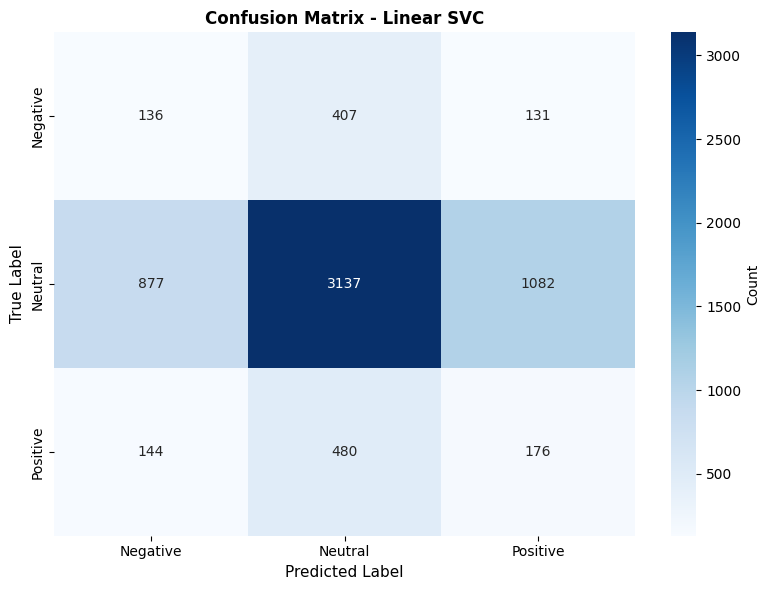

✓ Confusion Matrix Summary:
   Neutral samples (majority):  3137 correct out of 5096
   Sentiment samples (minority): 312 correct out of 1474
   Total correct: 3449 / 6570



In [12]:
## 8. Model Interpretation: Confusion Matrix

# Visualize model predictions on test set using a confusion matrix heatmap

from sklearn.metrics import confusion_matrix

print("\nGenerating confusion matrix heatmap...\n")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            cbar_kws={'label': 'Count'})

ax.set_title('Confusion Matrix - Linear SVC', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

print(f"✓ Confusion Matrix Summary:")
print(f"   Neutral samples (majority):  {cm[1,1]} correct out of {cm[1,:].sum()}")
print(f"   Sentiment samples (minority): {cm[0,0] + cm[2,2]} correct out of {cm[0,:].sum() + cm[2,:].sum()}")
print(f"   Total correct: {cm.trace()} / {cm.sum()}\n")

## 8.1 Feature Importance: Most Influential Words

Understanding which words drive sentiment classification is crucial for model interpretability and validation. We extract the top TF-IDF features with highest coefficients for each sentiment class from the trained Linear SVC model.

In [13]:
## Extract and Display Top Features for Each Sentiment Class

# Extract top features using utility function
sentiment_features, class_names = extract_top_features(
    final_model.model,
    final_model.tfidf,
    n_features=15
)

# Print formatted output
print_top_features(sentiment_features, class_names)


TOP INFLUENTIAL WORDS BY SENTIMENT CLASS

────────────────────────────────────────────────────────────────────────────────────────────────────
CLASS: NEGATIVE
────────────────────────────────────────────────────────────────────────────────────────────────────

  ✓ WORDS STRONGLY ASSOCIATED WITH NEGATIVE (High Coefficients):
     1. placement non broker      coef: +0.4786
     2. number company effective  coef: +0.4465
     3. non gaap financial        coef: +0.3938
     4. respect entity announce   coef: +0.3567
     5. prnewswire com news       coef: +0.3500
     6. com view original         coef: +0.3477
     7. imply date upside         coef: +0.3447
     8. visit bloomberg           coef: +0.3126
     9. money common share        coef: +0.3020
    10. percent upside potential  coef: +0.2880
    11. free cash flow            coef: +0.2872
    12. number toll free          coef: +0.2827
    13. date date tsx             coef: +0.2769
    14. constitute forward look   coef: +0.2747
 

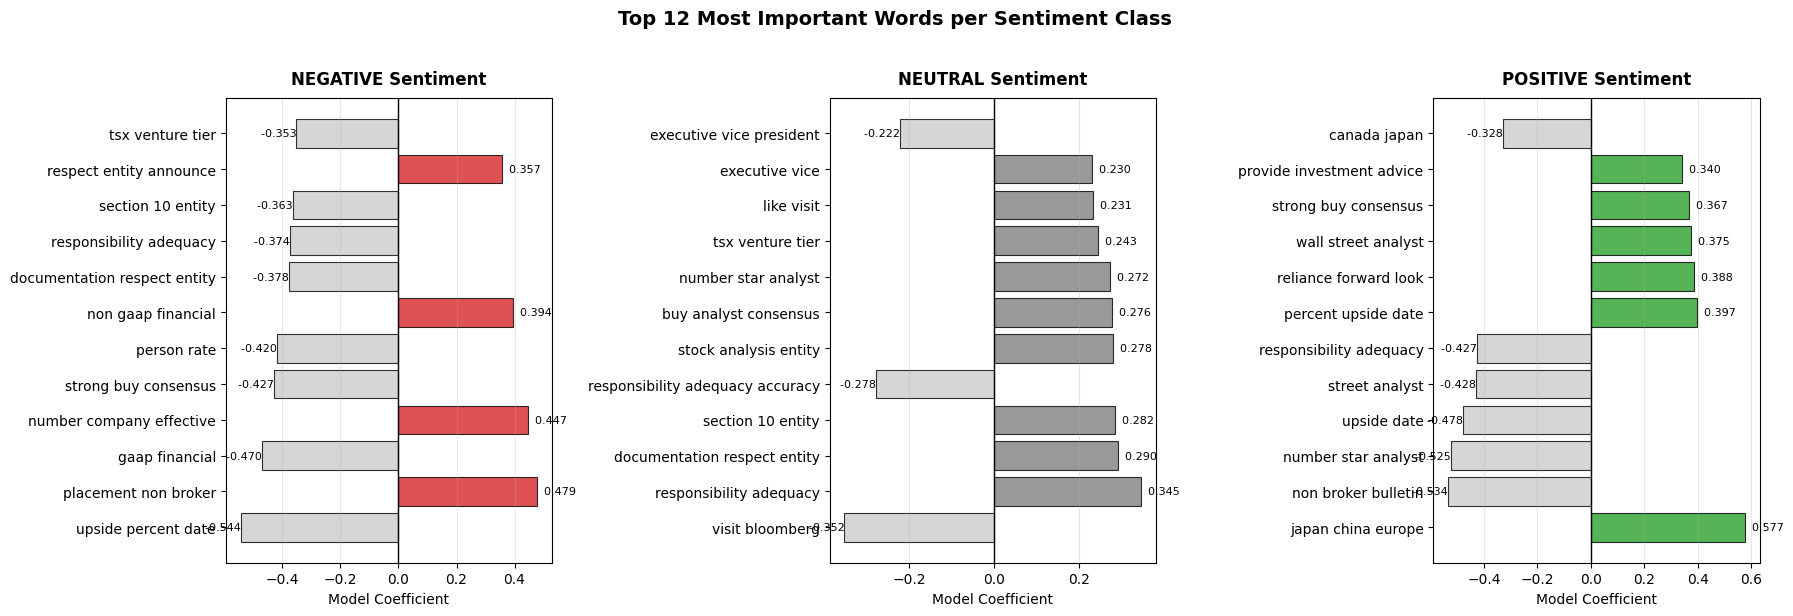

Chart Legend:
  • Darker colors: Words strongly associated with the sentiment
  • Lighter colors: Words against the sentiment (appear in opposite class)
  • Coefficient magnitude indicates word importance



In [14]:
## Visualize Top Features by Sentiment Class

plot_features_by_class(final_model.model, final_model.tfidf, n_features=12)

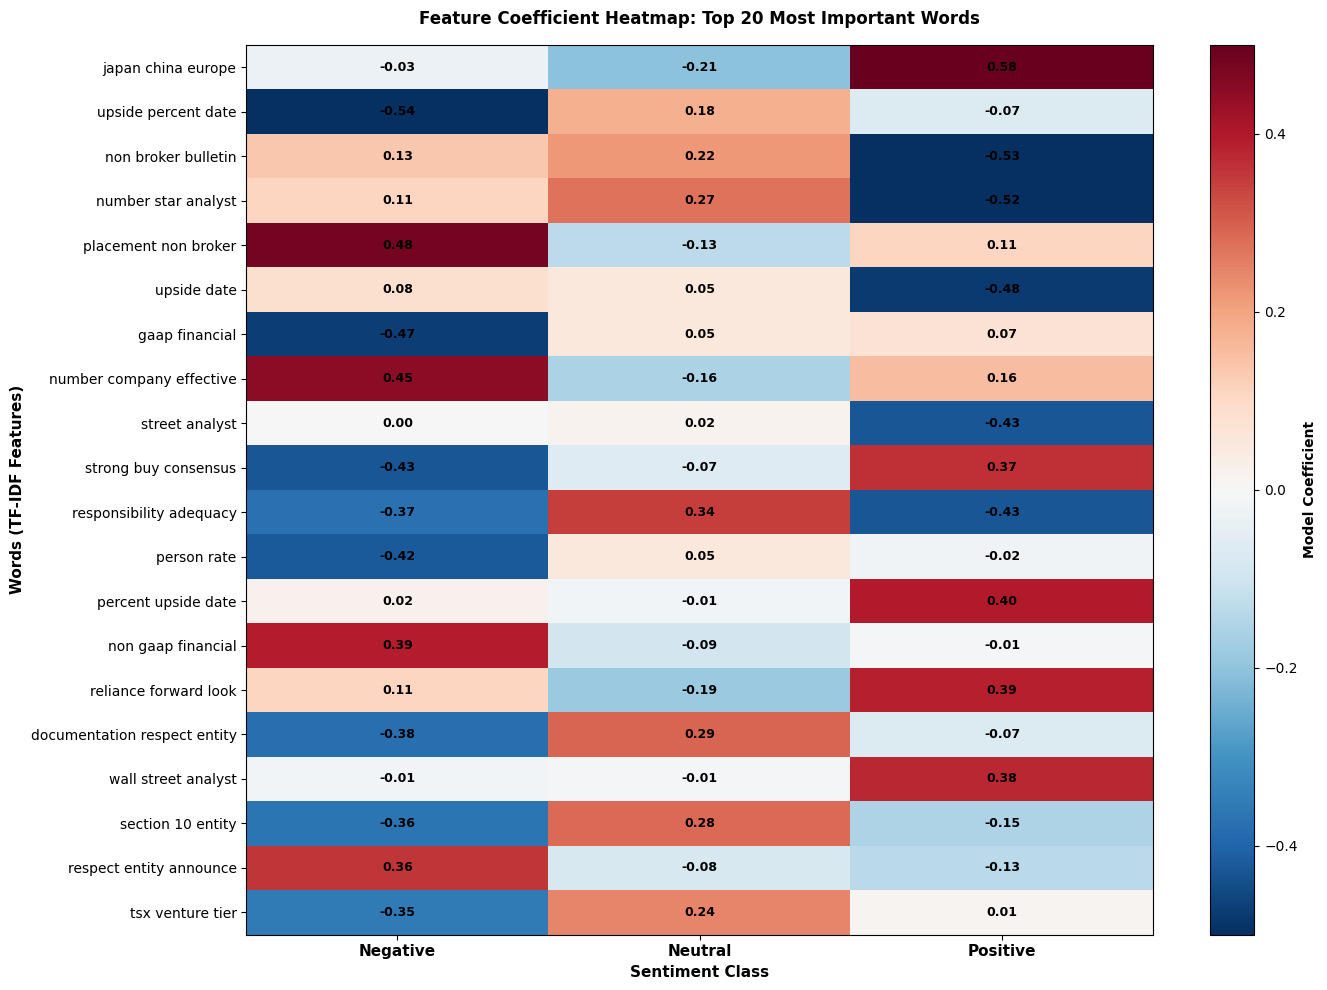

Heatmap Interpretation:
  • Blue regions: Negative coefficient (word evidence AGAINST that class)
  • Red regions: Positive coefficient (word evidence FOR that class)
  • Darker shades: Stronger influence on classification
  • Notice how words cluster around their dominant sentiment class



In [15]:
## Feature Importance Heatmap: Cross-Class Comparison

plot_feature_heatmap(final_model.model, final_model.tfidf, n_features=20)

## 8. Financial Backtesting: Confidence-Weighted Trading Strategies

We test the predictive power of sentiment on actual stock prices using confidence-weighted position sizing.

**Position Sizing Strategy**:
- Each trading day, position size = model confidence (0-1 range) × scaling factor
- Scaling factor targets 1.5x gross leverage daily (150% exposure)
- Scales naturally: more signals → smaller per-signal size; fewer signals → larger per-signal size
- Non-neutral signals only (Neutral → cash, zero position)

**Implemented Strategies**:
1. **Long-Short**: Buy on Positive, Short on Negative, cash on Neutral
   - Exploits both bullish and bearish sentiment signals
2. **Long-Only**: Buy on Positive, cash otherwise
   - Conservative: only captures upside signals
3. **Benchmark**: Equal-weight buy-and-hold of all 47 unique stocks
   - Passive baseline for comparison

**Key Setup**:
- Train period: 26,280 articles (2017-01-03 to 2023-06-21)
- Test period: 6,570 articles (2023-06-21 to 2023-12-27)
- Returns: Pre-computed daily price changes in processed dataset
- Model: Linear SVC with confidence scores from decision function

In [16]:
## 9. Prepare Data for Financial Backtesting (TEST SET ONLY)

# Prepare TEST set with predictions and confidence scores for strategy simulation.
# Returns are already pre-computed in the processed dataset.

print("\n" + "="*70)
print("FINANCIAL BACKTESTING SETUP (TEST SET ONLY)")
print("="*70)

print("\nStep 1: Preparing test set with predictions and confidence scores...")
test_df_full = df.loc[test_idx].copy()
test_df_full['date'] = pd.to_datetime(test_df_full['date'])

# Align predictions and confidence with dataframe index
test_df_full['pred_svm'] = pd.Series(y_pred, index=test_idx)
test_df_full['confidence'] = pd.Series(confidence_scores, index=test_idx)

print(f"  ✓ Test set prepared: {len(test_df_full)} articles with predictions")
print(f"  ✓ Test period: {test_df_full['date'].min().date()} to {test_df_full['date'].max().date()}")

print("\nStep 2: Using pre-computed returns from processed dataset...")
test_df_full['realized_return'] = test_df_full['return']
print(f"  ✓ Returns loaded for {len(test_df_full)} articles\n")


FINANCIAL BACKTESTING SETUP (TEST SET ONLY)

Step 1: Preparing test set with predictions and confidence scores...


  ✓ Test set prepared: 6570 articles with predictions
  ✓ Test period: 2023-06-21 to 2023-12-27

Step 2: Using pre-computed returns from processed dataset...
  ✓ Returns loaded for 6570 articles



In [17]:
## 9.1 Build Trading Strategies (Confidence-Weighted Position Sizing)

# Implement strategies using confidence-weighted position sizing with leverage targeting.
# - Each day: size positions by model confidence
# - Non-neutral signals only (neutral = cash)
# - Target leverage: 1.5x (150% gross exposure)

from utils.financial_simulation import backtest_strategies_confidence_weighted, compute_cumulative_performance_by_date

print("Step 3: Building confidence-weighted trading strategies...\n")
print(f"  Test set shape before backtest: {test_df_full.shape}")
print(f"  Test set columns: {list(test_df_full.columns)}")
print(f"  Date column dtype: {test_df_full['date'].dtype}\n")

print("  Position Sizing Logic:")
print("    - Long signals sized by confidence")
print("    - Short signals sized by confidence")
print("    - Neutral signals = 0 (cash)")
print("    - Daily leverage target: 1.5x (150% gross exposure)")
print("    - Scales naturally: more signals → smaller per-signal")
print("               fewer signals → larger per-signal")

print("\n  Strategies:")
print("    Long-Only: Takes long positions on positive signals only")
print("    Long-Short: Long on positive, short on negative, cash on neutral")
print("    Benchmark: Equal-weight buy-hold of ALL unique stocks\n")

test_df_full = backtest_strategies_confidence_weighted(
    test_df_full,
    price_col='realized_return',
    pred_col='pred_svm',
    confidence_col='confidence',
    target_leverage=1.5,
    date_col='date'
)
print("✓ Strategies implemented with confidence-weighted sizing")

print("\nStep 4: Computing cumulative returns by date...")
cum_perf = compute_cumulative_performance_by_date(test_df_full, date_col='date')
print(f"✓ Cumulative performance calculated\n")

print(f"Backtest period: {test_df_full['date'].min().date()} to {test_df_full['date'].max().date()}")
print(f"Total trades: {len(test_df_full)}")
print(f"Unique stocks: {test_df_full['ticker'].nunique()}\n")

Step 3: Building confidence-weighted trading strategies...

  Test set shape before backtest: (6570, 13)
  Test set columns: ['article_id', 'date', 'ticker', 'label', 'bert_input', 'tfidf_input', 'curr_day_price', 'next_day_price', 'return', 'volatility_threshold', 'pred_svm', 'confidence', 'realized_return']
  Date column dtype: datetime64[us]

  Position Sizing Logic:
    - Long signals sized by confidence
    - Short signals sized by confidence
    - Neutral signals = 0 (cash)
    - Daily leverage target: 1.5x (150% gross exposure)
    - Scales naturally: more signals → smaller per-signal
               fewer signals → larger per-signal

  Strategies:
    Long-Only: Takes long positions on positive signals only
    Long-Short: Long on positive, short on negative, cash on neutral
    Benchmark: Equal-weight buy-hold of ALL unique stocks



✓ Strategies implemented with confidence-weighted sizing

Step 4: Computing cumulative returns by date...
✓ Cumulative performance calculated

Backtest period: 2023-06-21 to 2023-12-27
Total trades: 6570
Unique stocks: 47



Generating comprehensive backtest visualization...



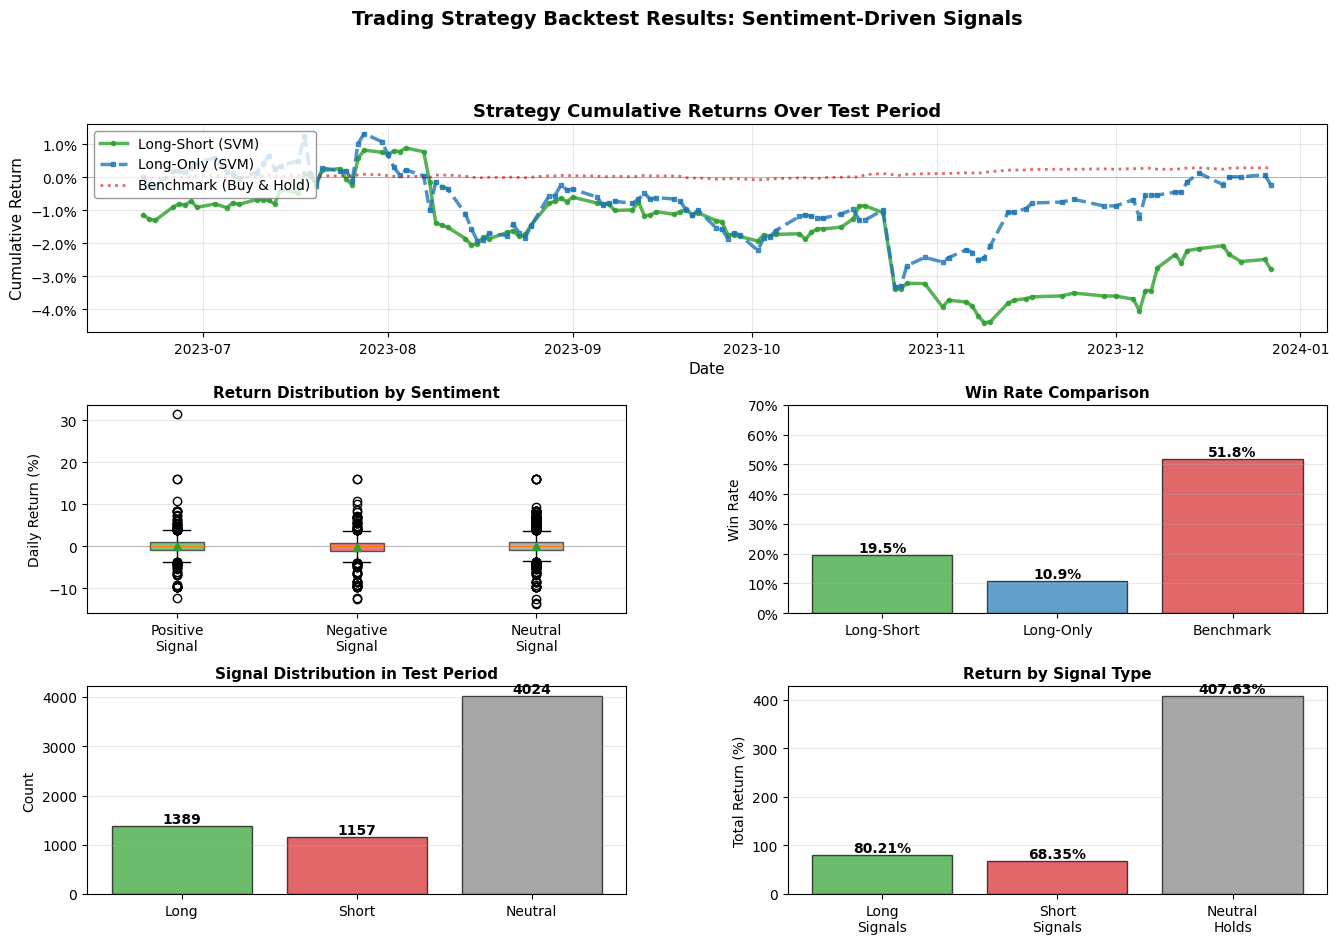

✓ Visualization complete



In [18]:
## 10. Backtest Results Visualization

# Plot comprehensive backtest results (5-subplot visualization)
plot_backtest_results(test_df_full, cum_perf)

In [19]:
## 11. Detailed Strategy Performance Metrics

# Calculate comprehensive performance metrics for all trading strategies.

print("\n" + "="*140)
print("STRATEGY PERFORMANCE METRICS SUMMARY")
print("="*140 + "\n")

metrics_list = [
    calculate_strategy_metrics(test_df_full['strat_long_short'], 'Long-Short (SVM)'),
    calculate_strategy_metrics(test_df_full['strat_long_only'], 'Long-Only (SVM)'),
    calculate_strategy_metrics(test_df_full['benchmark'], 'Benchmark (Buy & Hold)')
]
metrics_df = pd.DataFrame(metrics_list)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(metrics_df.to_string(index=False))
print("\n" + "="*140)


STRATEGY PERFORMANCE METRICS SUMMARY

              Strategy  Total Return (%)  Num Trades  Win Rate (%)  Avg Win (%)  Avg Loss (%)  Profit Factor  Sharpe Ratio  Max Drawdown (%)
      Long-Short (SVM)         68.750991        6570     19.452055     1.956397     -1.878394       1.075179      0.217259        -65.510261
       Long-Only (SVM)         33.861105        6570     10.943683     1.862714     -1.903000       1.076115      0.159471        -96.266032
Benchmark (Buy & Hold)          9.267636        6570     51.796043     0.028484     -0.028398       1.101420      0.495021        -17.106774



In [20]:
## 11.1 Performance Breakdown by Sentiment Signal

# Show how each sentiment signal performs in terms of returns and win rates.

print("\nPERFORMANCE BY SENTIMENT SIGNAL")
print("="*100)

sentiment_df = sentiment_breakdown(test_df_full, pred_col='pred_svm', return_col='realized_return')
print(sentiment_df.to_string(index=False))

print("\n" + "="*100)


PERFORMANCE BY SENTIMENT SIGNAL
Sentiment  Count  Avg Return (%)  Total Return (%)  Win Rate (%)  Std Dev (%)
 Negative   1157       -0.059073        -68.347753     50.475367     2.261368
  Neutral   4024        0.101300        407.632404     52.186879     1.915321
 Positive   1389        0.057745         80.208470     51.763859     2.221122



In [21]:
## 11.2 Strategy Alpha (Excess Returns vs Benchmark)

# Calculate total returns by compounding daily returns (correct method)
# Aggregates returns by date (average daily P&L), then compounds

print("\nSTRATEGY ALPHA (Excess Return vs Benchmark)")
print("="*70)

# Aggregate returns by date, then compound
daily_perf = test_df_full.groupby('date')[['strat_long_short', 'strat_long_only', 'benchmark']].mean()

# Compound returns across all days
ls_total = ((1 + daily_perf['strat_long_short']).prod() - 1) * 100
lo_total = ((1 + daily_perf['strat_long_only']).prod() - 1) * 100
bm_total = ((1 + daily_perf['benchmark']).prod() - 1) * 100

print(f"\nBenchmark (Equal-Weight Buy-Hold) Total Return: {bm_total:+.2f}%\n")
print(f"  Long-Short (Confidence-Weighted):")
print(f"    Total Return: {ls_total:+7.2f}%")
print(f"    Alpha vs Benchmark: {ls_total - bm_total:+7.2f}% ← Excess return")

print(f"\n  Long-Only (Confidence-Weighted):")
print(f"    Total Return: {lo_total:+7.2f}%")
print(f"    Alpha vs Benchmark: {lo_total - bm_total:+7.2f}% ← Excess return")

print("\n" + "="*70)
print("Position sizing: Confidence-weighted, 1.5x leverage target")
print("Evaluated on TEST SET ONLY (forward-looking predictions)")
print("="*70 + "\n")


STRATEGY ALPHA (Excess Return vs Benchmark)

Benchmark (Equal-Weight Buy-Hold) Total Return: +8.40%

  Long-Short (Confidence-Weighted):
    Total Return: +154.68%
    Alpha vs Benchmark: +146.28% ← Excess return

  Long-Only (Confidence-Weighted):
    Total Return:  +80.47%
    Alpha vs Benchmark:  +72.08% ← Excess return

Position sizing: Confidence-weighted, 1.5x leverage target
Evaluated on TEST SET ONLY (forward-looking predictions)

